In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/figures
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
sys.path.append("simulations")

In [4]:
import polars as pl
import jax

from analysis import housemaze_model_data
from analysis import housemaze_user_data

from analysis import housemaze_analysis
from nicewebrl import dataframe
import configs

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


# Simulation data

In [33]:
def get_dir(model_name):
    return f"{configs.JAXMAZE_MODEL_DIR}/final/{model_name}/seed=*"
model_df = housemaze_model_data.get_model_data(
  qlearning_path=get_dir("qlearning"),
  # sf_path=get_dir("sf"),
  # dyna_path=get_dir("dyna"),
  # preplay_path=get_dir("preplay"),
  # search_path=f"{configs.JAXMAZE_MODEL_DIR}/search_algos",
  overwrite_episodes=True,
  overwrite_df=True,
  sf_eval_task_support=['train'],
  debug=True,
)

  0%|          | 0/10 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


qlearning: Generating maze episodes:   0%|          | 0/3 [00:00<?, ?it/s]

qlearning: Generating maze information:   0%|          | 0/3 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


...

qlearning: Generating maze information:   0%|          | 0/3 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


qlearning: Generating maze episodes:   0%|          | 0/3 [00:00<?, ?it/s]

qlearning: Generating maze information:   0%|          | 0/3 [00:00<?, ?it/s]

Cached model data to /Users/wilka/git/research/preplay_results/jaxmaze_model_data/final/qlearning/model_data_cache_episodes.pickle


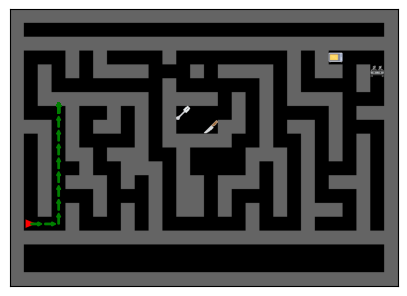

In [39]:
from analysis import housemaze_utils

housemaze_utils.render_path(model_df.filter(eval=False, success=0).episodes[0])

In [35]:
model_df['success'].mean()

0.3

# Human data

In [12]:
from glob import glob

USER_RESULTS_DIR = os.path.join(configs.JAXMAZE_USER_DIR, "user_data/exps")
human_data_pattern = "final*v2*"
files = f"{USER_RESULTS_DIR}/*{human_data_pattern}*.json"
# files = 'jaxemaze_data/*.json'
valid_files = list(set(glob(files)))
len(valid_files)

400

In [13]:
# %debug
user_df = housemaze_user_data.get_human_data(
    valid_files,
    overwrite_episode_data=False,
    overwrite_episode_info=False,
    require_finished=False,
    load_df_only=False,
    debug=False
)

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  pid = os.fork()
Failed to unpack record in /Users/wilka/git/research/preplay_results/jaxmaze_user_data/user_data/exps/user=4238060579_name=jaxmaze_final-v2-r1-t0-start_debug=0.json: unpack(b) received extra data.


Combining results:   0%|          | 0/400 [00:00<?, ?it/s]

In [14]:
# user_df['reuse'].unique()

# Analysis

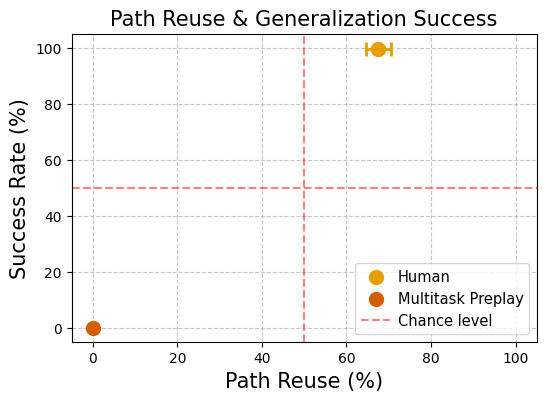

Filtered 0 rows with null success or reuse
Loading cached results from temp/statsfile.log_max_rt_reuse_1000.pkl
n no_reuse: 63
n reuse: 87


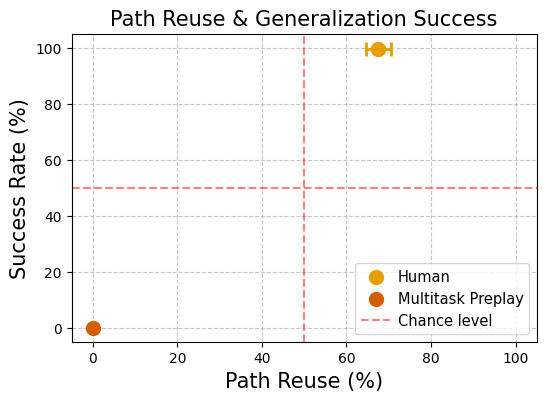

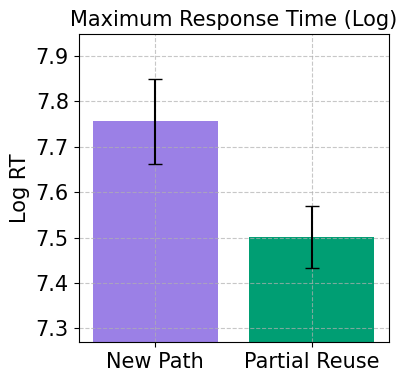

Filtered 0 rows with null success or reuse
Loading cached results from temp/statsfile.log_first_rt_reuse_1000.pkl
n no_reuse: 63
n reuse: 87


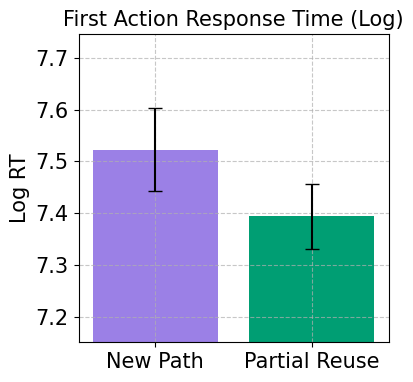

Filtered 0 rows with null success or reuse


KeyError: 'reuse'

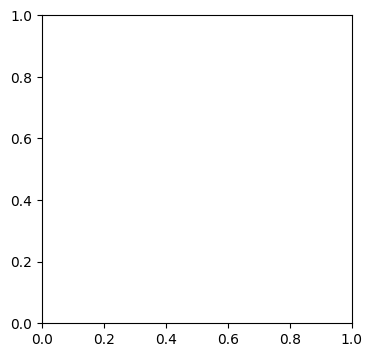

In [24]:
housemaze_analysis.path_reuse_results(
  user_df,
  model_df,
  save_dir=configs.JAXMAZE_RESULTS_DIR,
  tell_reuse=1,
  display_figs=True,
  save_figs=True,
  n_simulations=1000,
  verbosity=1,
  rereun_analysis=False,
  # rt_ylim=[[7,8][7,8], [1.5, 3], [2,5],[],
)

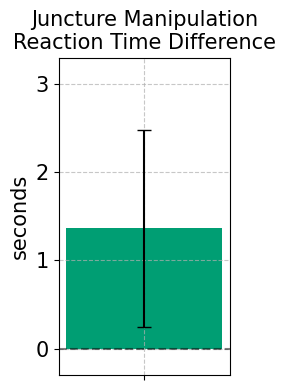

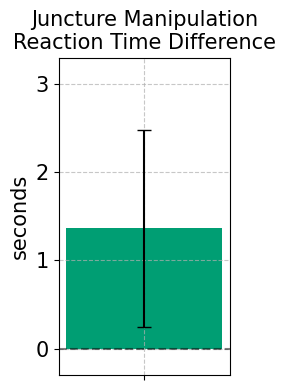

In [47]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
# save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.juncture_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  save_figs=True,
  display_figs=True,
  figsize=(2.5, 4),
  options=[('short', 0)],
  show_legend=False,
    measure='first_rt',
    ylim=[0, 3],
)

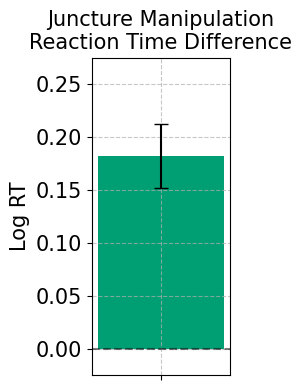

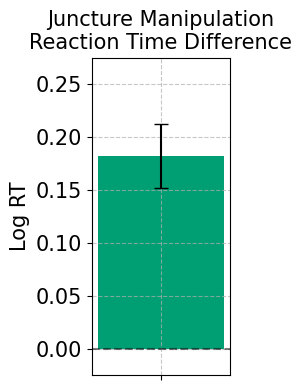

In [46]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
# save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.juncture_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  save_figs=True,
  display_figs=True,
  figsize=(2.5, 4),
  options=[('short', 0)],
  show_legend=False,
    # measure='first_rt',
  ylim=[0, .25],
)

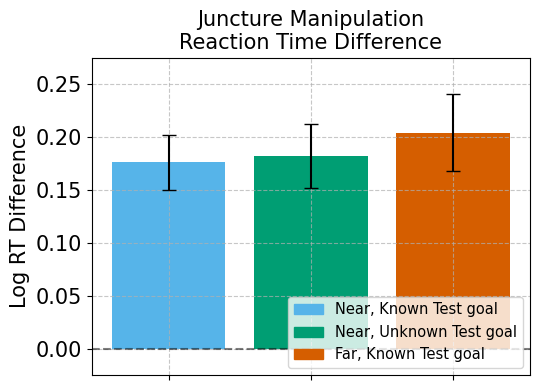

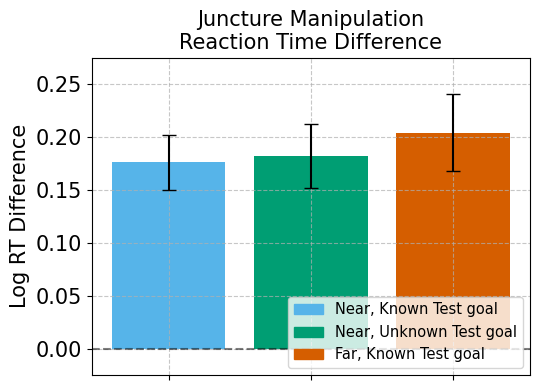

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze

In [24]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
# save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.juncture_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  save_figs=True,
  display_figs=True,
  # figsize=(2.5, 4),
  # options=[('short', 0)],
    # show_legend=False,
    ylim=[0, .25],
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
removed: user 2839222451 rate: 1.0 = 1/16. n=1
removed: user 3995656540 rate: 0.8888888955116272 = 8/16. n=9


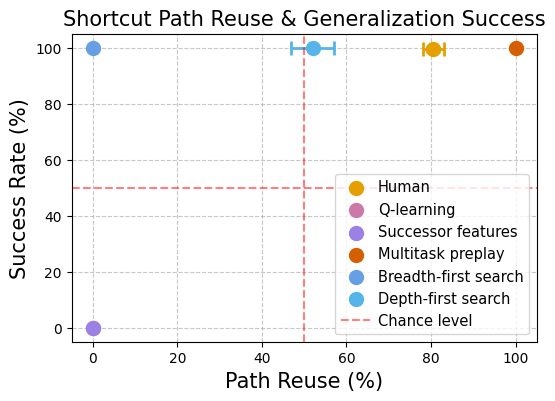

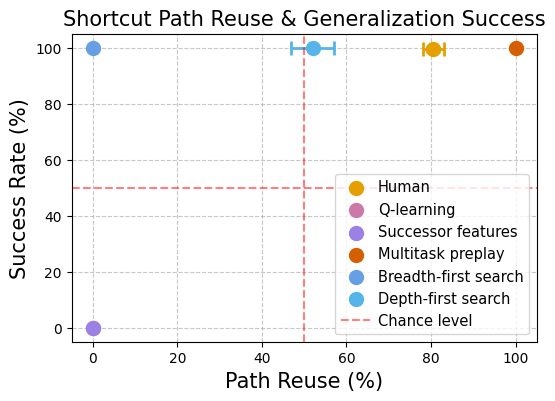

In [32]:
data_dir = '/Users/wilka/git/research/results/human_dyna/'
save_dir = f'{data_dir}/analysis_results/'
housemaze_analysis.shortcut_results(
    user_df,
    model_df,
    save_dir=save_dir,
    display_figs=True,
    save_figs=True)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


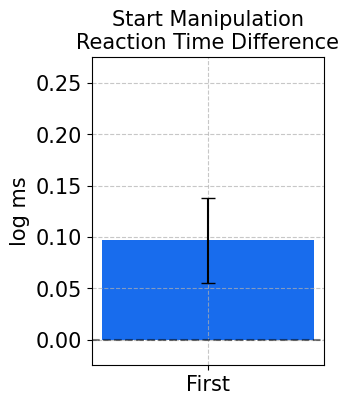

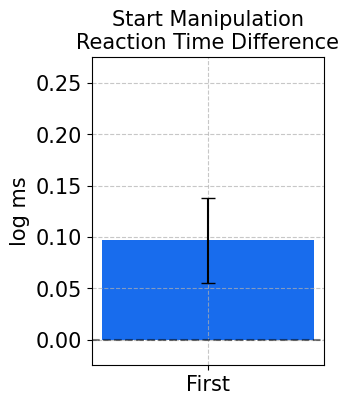

In [40]:
data_dir = '/Users/wilka/git/research/results/human_dyna/'
save_dir = f'{data_dir}/analysis_results/'
housemaze_analysis.start_results(
    user_df,
    # model_df,
    save_dir=save_dir,
    ylim=[0, .25],
    display_figs=True,
    save_figs=True)